# Histogram of Colors Used across all 3 genres

We will be repeating the k-means analysis done on each of the single notebooks, and then plotting the hues to see general trends.

In [106]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from IPython.display import display, HTML 
import matplotlib.colors as mcolors
import math
from collections import Counter
import matplotlib.cm as cm
import seaborn as sns

### Step 1: Load in the datasets

In [107]:
# Path to the directory containing the CSV files
english_directory_path = '/Users/rsudhir/Documents/GitHub/Data-Science-Project---Colors-Of-Romance/English-Analysis/English-Movie-CSVs'
hindi_directory_path = '/Users/rsudhir/Documents/GitHub/Data-Science-Project---Colors-Of-Romance/Hindi-Analysis/Hindi-Movie-CSVs'
korean_directory_path = '/Users/rsudhir/Documents/GitHub/Data-Science-Project---Colors-Of-Romance/Korean-Analysis/Korean-Movie-CSVs'

# List to hold each DataFrame
english_dfs = []
hindi_dfs = []
korean_dfs = []

# Loop through the files in the directory and load each CSV
for i in range(1, 26):
    english_file_path = os.path.join(english_directory_path, f'{i}.csv')
    hindi_file_path = os.path.join(hindi_directory_path, f'{i}.csv')
    korean_file_path = os.path.join(korean_directory_path, f'{i}.csv')

    df1 = pd.read_csv(english_file_path)
    df2 = pd.read_csv(hindi_file_path)
    df3 = pd.read_csv(korean_file_path)

    # Drop columns with NaN values
    df1 = df1.drop(columns=['color_10_r', 'color_10_g', 'color_10_b'])
    df2 = df2.drop(columns=['color_10_r', 'color_10_g', 'color_10_b'])
    df3 = df3.drop(columns=['color_10_r', 'color_10_g', 'color_10_b'])
    
    # Add a column to indicate which movie the data is from
    df1['movie_id'] = i
    df2['movie_id'] = i
    df3['movie_id'] = i
    
    english_dfs.append(df1)
    hindi_dfs.append(df2)
    korean_dfs.append(df3)

# Combine all DataFrames into a single DataFrame
english_combined_df = pd.concat(english_dfs, ignore_index=True)
hindi_combined_df = pd.concat(hindi_dfs, ignore_index=True)
korean_combined_df = pd.concat(korean_dfs, ignore_index=True)


# Display the combined DataFrame to ensure it looks correct
display(english_combined_df.head())
display(hindi_combined_df.head())
display(korean_combined_df.head())

,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_r,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id
0,output_0000001.png,94,76,59,210,190,185,28,24,21,...,58,26,24,169,174,174,163,160,165,1
1,output_0000002.png,38,36,28,191,177,178,129,114,101,...,164,132,118,156,148,156,100,88,100,1
2,output_0000003.png,126,109,90,28,24,19,196,180,163,...,170,168,165,178,180,163,71,63,34,1
3,output_0000004.png,41,32,30,94,81,72,105,100,90,...,155,156,154,83,89,101,152,148,156,1
4,output_0000005.png,32,27,26,196,174,161,121,93,80,...,119,130,150,148,148,140,73,77,96,1


,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_r,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id
0,output_0000001.png,117,55,10,232,219,96,231,90,12,...,136,91,33,180,162,100,180,173,96,1
1,output_0000002.png,4,4,4,8,4,4,8,4,4,...,8,4,4,8,4,4,8,4,4,1
2,output_0000003.png,199,163,104,17,17,8,170,130,77,...,27,69,69,108,140,132,100,148,134,1
3,output_0000004.png,168,147,89,106,90,47,9,9,6,...,187,5,47,89,122,140,44,61,73,1
4,output_0000005.png,37,49,32,186,199,163,135,139,109,...,88,106,100,130,162,156,192,26,50,1


,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_r,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id
0,output_0000001.png,53,53,38,169,195,201,112,123,116,...,130,139,148,76,100,94,116,132,84,1
1,output_0000002.png,106,119,107,150,153,145,38,41,34,...,57,66,41,44,60,55,156,172,156,1
2,output_0000003.png,187,210,188,77,76,71,31,35,36,...,120,139,132,108,92,75,60,84,76,1
3,output_0000004.png,214,228,250,245,245,249,184,202,250,...,186,212,251,188,183,236,215,211,211,1
4,output_0000005.png,117,111,98,17,18,16,172,165,166,...,145,139,148,83,82,85,156,108,94,1


In [113]:

# Define the number of segments
num_segments = 5

# Loop through each movie and create a segment ID
for df in [english_combined_df, hindi_combined_df, korean_combined_df]:
    df['segment_id'] = df.groupby('movie_id').cumcount() // (df.groupby('movie_id')['frame_path'].transform('count') // num_segments)

In [114]:
display(english_combined_df.head(10))
display(hindi_combined_df.head(10))
display(korean_combined_df.head(10))

,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id,segment_id
0,output_0000001.png,94,76,59,210,190,185,28,24,21,...,26,24,169,174,174,163,160,165,1,0
1,output_0000002.png,38,36,28,191,177,178,129,114,101,...,132,118,156,148,156,100,88,100,1,0
2,output_0000003.png,126,109,90,28,24,19,196,180,163,...,168,165,178,180,163,71,63,34,1,0
3,output_0000004.png,41,32,30,94,81,72,105,100,90,...,156,154,83,89,101,152,148,156,1,0
4,output_0000005.png,32,27,26,196,174,161,121,93,80,...,130,150,148,148,140,73,77,96,1,0
5,output_0000006.png,204,198,188,40,32,28,134,119,107,...,91,94,149,147,156,172,92,84,1,0
6,output_0000007.png,202,184,174,55,44,37,155,133,122,...,152,158,100,96,102,181,132,124,1,0
7,output_0000008.png,32,33,26,140,117,102,194,176,163,...,105,103,163,164,153,159,156,156,1,0
8,output_0000009.png,186,173,161,39,32,27,144,132,122,...,154,156,163,164,161,104,98,100,1,0
9,output_0000010.png,35,30,26,186,173,161,122,101,88,...,156,146,94,90,93,157,100,91,1,0


,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id,segment_id
0,output_0000001.png,117,55,10,232,219,96,231,90,12,...,91,33,180,162,100,180,173,96,1,0
1,output_0000002.png,4,4,4,8,4,4,8,4,4,...,4,4,8,4,4,8,4,4,1,0
2,output_0000003.png,199,163,104,17,17,8,170,130,77,...,69,69,108,140,132,100,148,134,1,0
3,output_0000004.png,168,147,89,106,90,47,9,9,6,...,5,47,89,122,140,44,61,73,1,0
4,output_0000005.png,37,49,32,186,199,163,135,139,109,...,106,100,130,162,156,192,26,50,1,0
5,output_0000006.png,129,114,88,30,30,21,174,196,165,...,80,67,94,67,33,157,178,165,1,0
6,output_0000007.png,32,32,28,178,200,169,117,114,95,...,142,116,140,148,140,108,156,116,1,0
7,output_0000008.png,182,218,194,29,26,23,108,112,96,...,144,140,148,141,131,100,156,100,1,0
8,output_0000009.png,75,68,55,117,127,105,16,22,17,...,92,100,156,149,126,133,155,148,1,0
9,output_0000010.png,149,169,136,29,27,22,118,123,98,...,132,91,132,140,140,116,156,134,1,0


,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id,segment_id
0,output_0000001.png,53,53,38,169,195,201,112,123,116,...,139,148,76,100,94,116,132,84,1,0
1,output_0000002.png,106,119,107,150,153,145,38,41,34,...,66,41,44,60,55,156,172,156,1,0
2,output_0000003.png,187,210,188,77,76,71,31,35,36,...,139,132,108,92,75,60,84,76,1,0
3,output_0000004.png,214,228,250,245,245,249,184,202,250,...,212,251,188,183,236,215,211,211,1,0
4,output_0000005.png,117,111,98,17,18,16,172,165,166,...,139,148,83,82,85,156,108,94,1,0
5,output_0000006.png,76,70,58,186,165,172,136,117,107,...,109,109,147,150,138,47,27,24,1,0
6,output_0000007.png,104,119,117,28,31,28,178,179,168,...,82,100,101,79,62,63,53,45,1,0
7,output_0000008.png,152,163,215,91,95,103,32,29,28,...,183,180,44,60,61,172,168,184,1,0
8,output_0000009.png,119,143,177,30,27,25,90,107,116,...,87,78,93,63,60,124,84,148,1,0
9,output_0000010.png,136,148,194,40,38,36,164,180,233,...,85,79,149,129,146,92,116,172,1,0


In [115]:


# Define the number of clusters for each segment
num_clusters_per_segment = 15  # You can adjust this number

# Function to classify colors by tone
def classify_color_by_tone(hsv):
    hue = hsv[0] * 360  # Convert hue from [0, 1] to [0, 360]
    
    if hue < 30 or hue >= 330:
        return 'red'
    elif 30 <= hue < 60:
        return 'orange'
    elif 60 <= hue < 90:
        return 'yellow'
    elif 90 <= hue < 120:
        return 'yellow/green'
    elif 120 <= hue < 150:
        return 'green'
    elif 150 <= hue < 180:
        return 'neon green'
    elif 180 <= hue < 210:
        return 'cyan'
    elif 210 <= hue < 240:
        return 'blue'
    elif 240 <= hue < 270:
        return 'dark blue'
    elif 270 <= hue < 300:
        return 'magenta'
    elif 300 <= hue < 330:
        return 'pink'
    else:
        return 'unknown'

# Function to process each dataset and classify colors by tone
def process_dataset_and_classify_tones(combined_df):
    # Create a list to hold all cluster centers
    all_cluster_centers = []

    # Group the data by movie and segment
    grouped = combined_df.groupby(['movie_id', 'segment_id'])

    for (movie_id, segment_id), group in grouped:
        # Reshape the data to have each color as an individual row
        colors = []
        for i in range(1, 10):  # Looping through the top 9 dominant colors
            colors.append(group[[f'color_{i}_r', f'color_{i}_g', f'color_{i}_b']].dropna().values)

        # Combine all the colors into a single array
        colors_array = np.vstack(colors)

        # Check if there are enough data points to perform clustering
        if len(colors_array) >= num_clusters_per_segment:
            # Perform K-Means clustering on the colors within this segment
            kmeans = KMeans(n_clusters=num_clusters_per_segment, n_init='auto', random_state=42)
            kmeans.fit(colors_array)

            # Store the cluster centers
            all_cluster_centers.append(kmeans.cluster_centers_)
        else:
            print(f"Skipping segment {segment_id} of movie {movie_id} due to insufficient data points.")
    
    # Combine all the cluster centers into a single array
    all_cluster_centers = np.vstack(all_cluster_centers)
    
    # Convert the RGB cluster centers to HSV and classify them by tone
    color_tones = [classify_color_by_tone(mcolors.rgb_to_hsv([r/255, g/255, b/255])) for r, g, b in all_cluster_centers]

    # Count the occurrences of each tone
    tone_counts = Counter(color_tones)

    # Calculate the percentage of each tone
    total_colors = len(all_cluster_centers)
    tone_percentages = {tone: (count / total_colors) * 100 for tone, count in tone_counts.items()}

    # Return the tone percentages and counts
    return tone_percentages, tone_counts, all_cluster_centers

# Process each dataset
english_tone_percentages, english_tone_counts, english_cluster_centers = process_dataset_and_classify_tones(english_combined_df)
hindi_tone_percentages, hindi_tone_counts, hindi_cluster_centers = process_dataset_and_classify_tones(hindi_combined_df)
korean_tone_percentages, korean_tone_counts, korean_cluster_centers = process_dataset_and_classify_tones(korean_combined_df)

# Sort and display the results for English movies 
sorted_english_tones = sorted(english_tone_percentages.items(), key=lambda x: x[1], reverse=True)

print("\nSummary of tone counts and percentages for English Movies (sorted by percentage):")
for tone, percentage in sorted_english_tones:
    count = english_tone_counts[tone]
    print(f"{tone.capitalize()}: {count} colors ({percentage:.2f}%)")

# Sort and display the results for Hindi movies 
sorted_hindi_tones = sorted(hindi_tone_percentages.items(), key=lambda x: x[1], reverse=True)

print("\nSummary of tone counts and percentages for English Movies (sorted by percentage):")
for tone, percentage in sorted_hindi_tones:
    count = hindi_tone_counts[tone]
    print(f"{tone.capitalize()}: {count} colors ({percentage:.2f}%)")

# Sort and display the results for Korean movies 
sorted_korean_tones = sorted(korean_tone_percentages.items(), key=lambda x: x[1], reverse=True)

print("\nSummary of tone counts and percentages for English Movies (sorted by percentage):")
for tone, percentage in sorted_hindi_tones:
    count = korean_tone_counts[tone]
    print(f"{tone.capitalize()}: {count} colors ({percentage:.2f}%)")


Skipping segment 5 of movie 6 due to insufficient data points.
Skipping segment 5 of movie 7 due to insufficient data points.
Skipping segment 5 of movie 8 due to insufficient data points.
Skipping segment 5 of movie 19 due to insufficient data points.
Skipping segment 5 of movie 1 due to insufficient data points.
Skipping segment 5 of movie 3 due to insufficient data points.
Skipping segment 5 of movie 5 due to insufficient data points.
Skipping segment 5 of movie 9 due to insufficient data points.
Skipping segment 5 of movie 12 due to insufficient data points.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (11) found smaller than n_clusters (15). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Skipping segment 5 of movie 1 due to insufficient data points.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (11) found smaller than n_clusters (15). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (11) found smaller than n_clusters (15). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (11) found smaller than n_clusters (15). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Skipping segment 5 of movie 21 due to insufficient data points.
Skipping segment 5 of movie 22 due to insufficient data points.

Summary of tone counts and percentages for English Movies (sorted by percentage):
Red: 692 colors (31.82%)
Orange: 526 colors (24.18%)
Cyan: 262 colors (12.05%)
Blue: 196 colors (9.01%)
Yellow: 180 colors (8.28%)
Neon green: 118 colors (5.43%)
Yellow/green: 73 colors (3.36%)
Green: 56 colors (2.57%)
Dark blue: 43 colors (1.98%)
Pink: 17 colors (0.78%)
Magenta: 12 colors (0.55%)

Summary of tone counts and percentages for English Movies (sorted by percentage):
Red: 711 colors (32.92%)
Orange: 415 colors (19.21%)
Cyan: 324 colors (15.00%)
Blue: 214 colors (9.91%)
Yellow: 123 colors (5.69%)
Neon green: 99 colors (4.58%)
Yellow/green: 96 colors (4.44%)
Green: 74 colors (3.43%)
Dark blue: 45 colors (2.08%)
Magenta: 32 colors (1.48%)
Pink: 27 colors (1.25%)

Summary of tone counts and percentages for English Movies (sorted by percentage):
Red: 526 colors (32.92%)
O

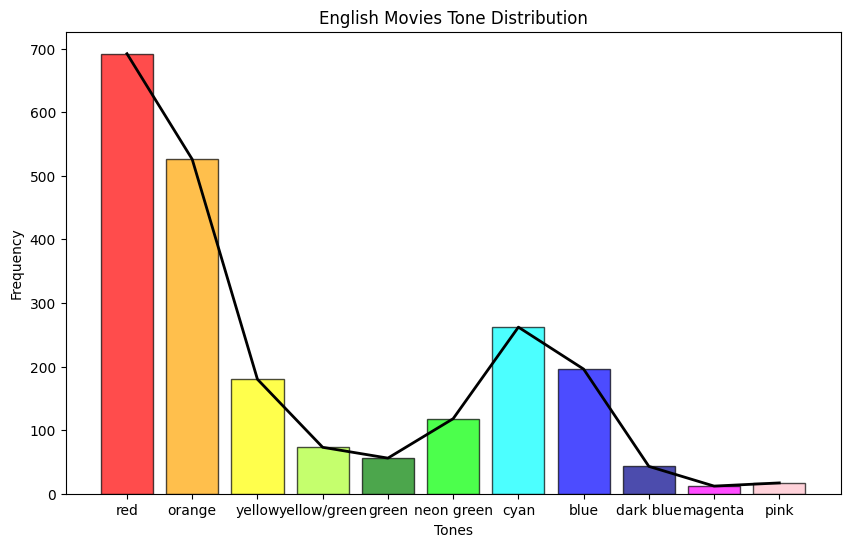

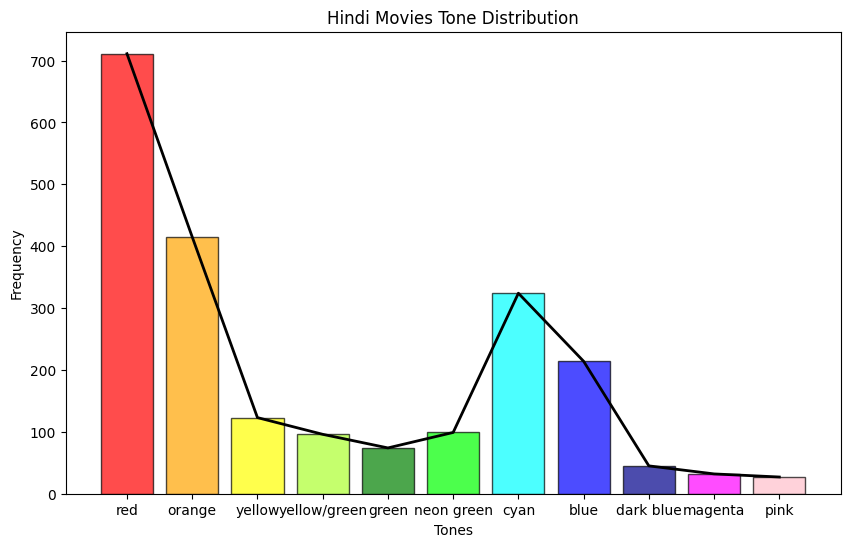

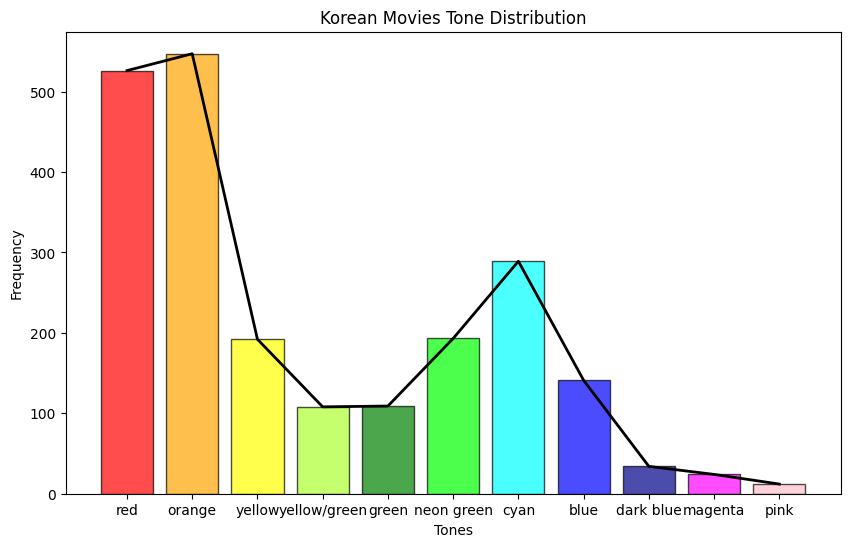

In [116]:
import numpy as np
import matplotlib.pyplot as plt

def plot_tone_histogram_with_line(tone_counts, title):
    # Ensure tones are sorted consistently by defining a consistent order
    sorted_tones = ['red', 'orange', 'yellow', 'yellow/green', 'green', 
                    'neon green', 'cyan', 'blue', 'dark blue', 
                    'magenta', 'pink']
    
    # Extract the counts in the sorted tone order
    sorted_counts = [tone_counts[tone] if tone in tone_counts else 0 for tone in sorted_tones]
    
    # Map tones to representative colors
    tone_colors = {
        'red': '#FF0000',
        'orange': '#FFA500',
        'yellow': '#FFFF00',
        'yellow/green': '#ADFF2F',
        'green': '#008000',
        'neon green': '#00FF00',
        'cyan': '#00FFFF',
        'blue': '#0000FF',
        'dark blue': '#00008B',
        'magenta': '#FF00FF',
        'pink': '#FFC0CB'
    }
    
    # Create the histogram
    plt.figure(figsize=(10, 6))
    bars = plt.bar(sorted_tones, sorted_counts, color=[tone_colors[tone] for tone in sorted_tones], alpha=0.7, edgecolor='black')

    # Get the positions of the bars' centers
    bar_positions = [bar.get_x() + bar.get_width() / 2 for bar in bars]
    
    # Plot a line connecting the midpoints of the bars
    plt.plot(bar_positions, sorted_counts, 'k-', linewidth=2)
    
    # Title and labels
    title_str = f'{title} Tone Distribution'
    plt.title(title_str)
    plt.xlabel('Tones')
    plt.ylabel('Frequency')
    
    # Show the plot
    plt.show()

# Visualize the tone distribution for English, Hindi, and Korean Movies with a Line Plot
plot_tone_histogram_with_line(english_tone_counts, 'English Movies')
plot_tone_histogram_with_line(hindi_tone_counts, 'Hindi Movies')
plot_tone_histogram_with_line(korean_tone_counts, 'Korean Movies')

